# M3A6 - Segmentação Semântica

> **Resumo:** Segmentação classifica **cada pixel** da imagem. Comparamos três abordagens: o **SAM** (Meta, *zero-shot* — segmenta qualquer coisa sem conhecer a classe), a **YOLO-seg** (baseada nas 80 classes do COCO) e o **DeepLabV3** (torchvision, 21 classes do Pascal VOC). Testamos também no Sonic pra ver o *domain shift*.

> 📝 **Três tipos:** semântica (pixel → categoria), instância (separa objetos da mesma classe) e panóptica (combina as duas).

> ⚠️ **GPU recomendada.** O SAM é pesado — em CPU a inferência "segmentar tudo" pode levar vários minutos. No Colab: **Ambiente de execução → Alterar o tipo → GPU (T4)**.

Na prática de hoje vamos utilizar um modelo pré-treinado para segmentação semântica. Para a prática de hoje iremos utilizar a biblioteca  [Ultralytics](https://docs.ultralytics.com/).

Esse notebook está estruturado da seguinte forma.

- Introdução
- Segmentação Semântica
- Próximos passos
- ✅ Atividades Complementares (resolvidas)

## Introdução

**Segmentação** é a tarefa de classificar **cada pixel** de uma imagem, identificando a que região ou objeto ele pertence.
Existem três tipos principais:

| Tipo | O que faz | Exemplo |
|------|-----------|---------|
| **Semântica** | Classifica cada pixel por categoria (sem diferenciar instâncias) | "Todos os pixels de carro = azul" |
| **Instância** | Separa objetos individuais da mesma classe | "Carro 1 = azul, Carro 2 = verde" |
| **Panóptica** | Combina semântica + instância | Cada pixel recebe classe + ID de instância |

O modelo **SAM** (Segment Anything Model), da Meta AI, é um modelo de segmentação "universal"
que consegue segmentar **qualquer objeto** em qualquer imagem, sem precisar ser treinado
para classes específicas. Ele aprende o conceito genérico de "o que é um objeto".

Instalação para os que ainda não possuem a biblioteca instalada.

In [1]:
!pip install ultralytics

Importar as bibliotecas e Ler Imagens do Disco

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torchvision
import ultralytics

In [3]:
# TODO Atualize o path da imagem.
image = cv2.imread("street.jpeg")

# Verificar se a imagem foi carregada corretamente.
if image is None:
    print("ERRO: Imagem 'street.jpeg' não encontrada!")
    print("Faça upload do arquivo street.jpeg para o mesmo diretório do notebook.")
else:
    print(f"Imagem carregada com sucesso!")
    print(f"  Shape: {image.shape} (altura, largura, canais)")
    print(f"  Tipo: {image.dtype}")
    print(f"  Resolução: {image.shape[1]}x{image.shape[0]} pixels")

Imagem carregada com sucesso!
  Shape: (534, 800, 3) (altura, largura, canais)
  Tipo: uint8
  Resolução: 800x534 pixels


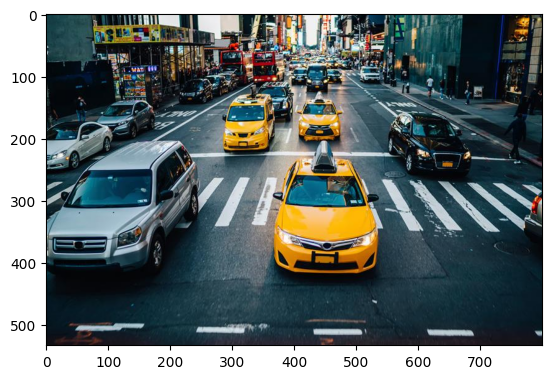

In [4]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

## Segmentação Semântica

Iremos carregar o modelo pré-treinado e visualizar seus resultados.

### Contexto de Modelos (Teoria da Aula do Professor)

Na aula teórica, o professor destaca três importantes arquiteturas clássicas e modernas de segmentação:

1. **U-Net**: Arquitetura clássica com formato de "U" altamente usada em imagens médicas. Ela combina um extrator de características convolucional (encoder) com uma etapa de reconstrução de pixels (decoder) por meio de conexões de salto (skip connections), o que permite recuperar detalhes precisos de contorno mesmo com bases de treino pequenas.
2. **Mask R-CNN**: Uma evolução da arquitetura Faster R-CNN que adiciona um ramo para prever máscaras de segmentação de instâncias no nível de pixels de forma paralela ao ramo de bounding box clássico.
3. **SAM (Segment Anything Model)**: Modelo desenvolvido pela Meta AI baseado na arquitetura **Transformers** (a mesma tecnologia que alimenta modelos de linguagem modernos como o ChatGPT e Gemini). Treinado em **11 milhões de imagens** com **1.1 bilhão de máscaras**, funciona de forma *zero-shot* (segmenta qualquer objeto mesmo sem ter sido treinado especificamente para aquela classe).

A versão `sam_b.pt` é a variante "base" (mais leve). Também existem `sam_l.pt` (large) e `sam_h.pt` (huge).


image 1/1 /content/street.jpeg: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 1 11, 1 12, 1 13, 1 14, 1 15, 1 16, 1 17, 1 18, 1 19, 1 20, 1 21, 1 22, 1 23, 1 24, 1 25, 1 26, 1 27, 1 28, 1 29, 1 30, 1 31, 1 32, 1 33, 1 34, 1 35, 1 36, 1 37, 1 38, 1 39, 1 40, 1 41, 1 42, 1 43, 1 44, 1 45, 1 46, 1 47, 1 48, 1 49, 1 50, 1 51, 1 52, 1 53, 1 54, 1 55, 1 56, 1 57, 1 58, 1 59, 1 60, 1 61, 1 62, 1 63, 1 64, 1 65, 1 66, 1 67, 1 68, 1 69, 1 70, 1 71, 1 72, 1 73, 1 74, 1 75, 1 76, 1 77, 1 78, 1 79, 1 80, 1 81, 1 82, 1 83, 1 84, 1 85, 1 86, 1 87, 1 88, 1 89, 1 90, 1 91, 1 92, 1 93, 1 94, 1 95, 1 96, 1 97, 1 98, 1 99, 1 100, 1 101, 1 102, 1 103, 1 104, 1 105, 1 106, 1 107, 1 108, 11183.4ms
Speed: 17.1ms preprocess, 11183.4ms inference, 6.8ms postprocess per image at shape (1, 3, 1024, 1024)


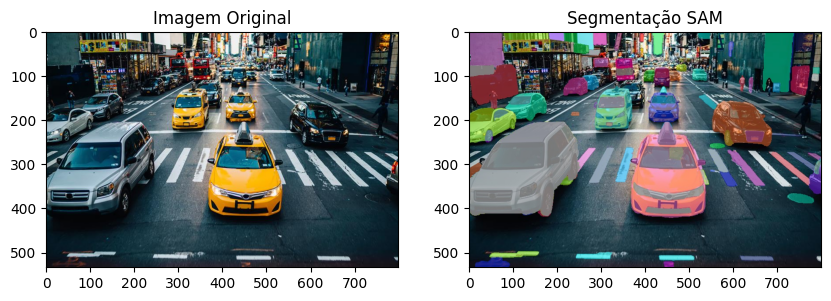

In [5]:
# Carregar o modelo SAM.
model = ultralytics.SAM("sam_b.pt")

# Roda a inferência do modelo SAM.
results = model("street.jpeg")

for i, result in enumerate(results):
    # Salva os resultados em uma imagem no disco.
    result.save(filename=f"results_{i}.jpg", boxes=False)

# Carrega a imagem que acabou de ser salva para visualizarmos.
results_image = cv2.imread("results_0.jpg")

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 8))
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Imagem Original")
axes[1].imshow(cv2.cvtColor(results_image, cv2.COLOR_BGR2RGB))
axes[1].set_title("Segmentação SAM")
plt.show()

### Análise dos Resultados (textual)

Vamos extrair dados quantitativos da segmentação para analisar os resultados.

In [6]:
# Extrair informações sobre os segmentos detectados.
for result in results:
    masks = result.masks
    if masks is not None:
        print(f"Total de segmentos detectados: {len(masks)}")
        print(f"Shape do tensor de máscaras: {masks.data.shape}")
        print()
        
        # Calcular a área de cada segmento em pixels.
        areas = []
        for idx, mask in enumerate(masks.data):
            area = mask.sum().item()
            areas.append(area)
        
        areas_np = np.array(areas)
        total_pixels = masks.data.shape[1] * masks.data.shape[2]
        
        print("--- Estatísticas dos segmentos ---")
        print(f"  Resolução da máscara: {masks.data.shape[2]}x{masks.data.shape[1]} pixels")
        print(f"  Total de pixels na imagem: {total_pixels:,}")
        print(f"  Área média dos segmentos: {areas_np.mean():.0f} pixels ({areas_np.mean()/total_pixels*100:.2f}%)")
        print(f"  Área mediana: {np.median(areas_np):.0f} pixels")
        print(f"  Maior segmento: {areas_np.max():.0f} pixels ({areas_np.max()/total_pixels*100:.2f}%)")
        print(f"  Menor segmento: {areas_np.min():.0f} pixels ({areas_np.min()/total_pixels*100:.2f}%)")
        print()
        
        # Mostrar os 10 maiores segmentos.
        top_indices = np.argsort(areas)[::-1][:10]
        print("--- Top 10 maiores segmentos ---")
        print(f"{'#':<6} {'Segmento':<12} {'Área (px)':<14} {'% da imagem':<12}")
        print("-" * 44)
        for rank, seg_idx in enumerate(top_indices):
            pct = areas[seg_idx] / total_pixels * 100
            print(f"{rank+1:<6} {seg_idx:<12} {areas[seg_idx]:<14.0f} {pct:<12.2f}")
    else:
        print("Nenhuma máscara foi gerada pelo modelo.")

Total de segmentos detectados: 109
Shape do tensor de máscaras: torch.Size([109, 534, 800])

--- Estatísticas dos segmentos ---
  Resolução da máscara: 800x534 pixels
  Total de pixels na imagem: 427,200
  Área média dos segmentos: 2401 pixels (0.56%)
  Área mediana: 882 pixels
  Maior segmento: 39081 pixels (9.15%)
  Menor segmento: 71 pixels (0.02%)

--- Top 10 maiores segmentos ---
#      Segmento     Área (px)      % da imagem 
--------------------------------------------
1      7            39081          9.15        
2      2            38897          9.11        
3      25           28324          6.63        
4      18           10471          2.45        
5      66           7913           1.85        
6      34           7711           1.81        
7      8            7462           1.75        
8      1            6953           1.63        
9      19           6465           1.51        
10     5            5936           1.39        


E assim podemos utilizar o modelo [SAM - Segment Anything](https://aidemos.meta.com/segment-anything) utilizando a biblioteca Ultralytics.

## Próximos Passos e Referências

Nas próximas práticas vamos trabalhar com problemas reais que envolvem Visão Computacional.

Uma lista não exaustiva de referências segue:

- https://docs.ultralytics.com/
- https://pytorch.org/
- https://docs.pytorch.org/vision/main/models.html
- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares

Nesta seção, vamos aprofundar nossos estudos de segmentação:
1. **YOLO para Segmentação (YOLO-seg):** Comparar a segmentação de instâncias da YOLOv11n-seg com a segmentação "universal" do SAM.
2. **Segmentando o Sonic (SAM vs YOLO-seg):** Testar os dois modelos na imagem do Sonic para ver como eles reagem a desenhos/personagens fictícios.
3. **Segmentação com Torchvision (DeepLabV3):** Demonstrar como realizar segmentação semântica clássica usando os modelos nativos do PyTorch/Torchvision.

### 1. YOLO-seg na imagem do Tráfego (`street.jpeg`)

Vamos carregar o modelo de segmentação `yolo11n-seg.pt` (nano segmentação) treinado no COCO. Diferente do SAM, ele é supervisionado e nos dará a classe exata de cada objeto segmentado (ex: "car", "person").

In [7]:
# Carregar o modelo YOLO de segmentação
yolo_seg = ultralytics.YOLO("yolo11n-seg.pt")

# Rodar inferência na rua
results_yolo_seg = yolo_seg("street.jpeg")

# Contar classes segmentadas
for result in results_yolo_seg:
    masks = result.masks
    if masks is not None:
        print(f"Total de objetos segmentados pela YOLO-seg: {len(masks)}")
        
        # Contagem por classe
        from collections import Counter
        class_counts = Counter()
        for box in result.boxes:
            cls_id = int(box.cls[0])
            cls_name = result.names[cls_id]
            class_counts[cls_name] += 1
            
        print("--- Contagem por classe (YOLO-seg) ---")
        for cls_name, count in class_counts.most_common():
            print(f"  {cls_name}: {count}")
            
        # Salvar resultado visual
        result.save(filename="street_yolo_seg.jpg")
    else:
        print("Nenhum objeto segmentado pela YOLO.")


image 1/1 /content/street.jpeg: 448x640 5 persons, 14 cars, 1 truck, 61.8ms
Speed: 2.1ms preprocess, 61.8ms inference, 2.8ms postprocess per image at shape (1, 3, 448, 640)
Total de objetos segmentados pela YOLO-seg: 20
--- Contagem por classe (YOLO-seg) ---
  car: 14
  person: 5
  truck: 1


### 2. Segmentação do Sonic: SAM vs YOLO-seg

Vamos usar a imagem do Sonic (`sonic.jpg`) para comparar as duas abordagens de segmentação.

In [8]:
import os

# Caminho para a imagem do Sonic
sonic_path = "/content/sonic.jpg"
if not os.path.exists(sonic_path):
    sonic_path = "sonic.jpg"
if not os.path.exists(sonic_path):
    sonic_path = "../../img/sonic.jpg"
if not os.path.exists(sonic_path):
    sonic_path = "img/sonic.jpg"

if not os.path.exists(sonic_path):
    print("ERRO: Imagem do Sonic não encontrada!")
else:
    sonic_img = cv2.imread(sonic_path)
    
    # 1. Segmentação com SAM
    sam_model = ultralytics.SAM("sam_b.pt")
    sam_results = sam_model(sonic_path)
    for res in sam_results:
        res.save(filename="sonic_sam_seg.jpg", boxes=False)
        
    # 2. Segmentação com YOLO-seg
    yolo_seg_results = yolo_seg(sonic_path)
    for res in yolo_seg_results:
        res.save(filename="sonic_yolo_seg.jpg")


image 1/1 /content/sonic.jpg: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 1 11, 1 12, 1 13, 1 14, 1 15, 1 16, 1 17, 1 18, 1 19, 1 20, 1 21, 1 22, 1 23, 1 24, 1 25, 1 26, 1 27, 1 28, 1 29, 1 30, 1 31, 1 32, 1 33, 1 34, 1 35, 1 36, 1 37, 1 38, 1 39, 1 40, 1 41, 1 42, 1 43, 1 44, 1 45, 1 46, 1 47, 1 48, 1 49, 1 50, 1 51, 1 52, 1 53, 1 54, 1 55, 1 56, 1 57, 1 58, 1 59, 11043.3ms
Speed: 4.9ms preprocess, 11043.3ms inference, 5.0ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 /content/sonic.jpg: 384x640 (no detections), 65.9ms
Speed: 1.8ms preprocess, 65.9ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)


#### Visualização Lado a Lado (Sonic)

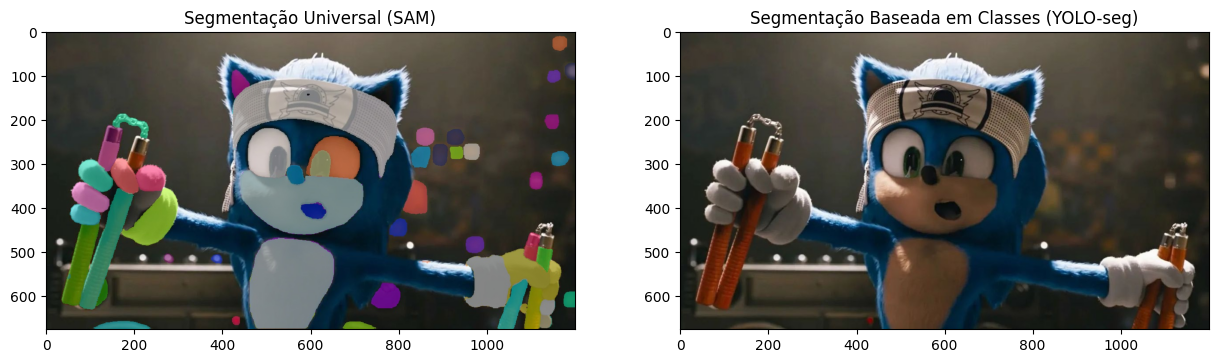

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

if os.path.exists("sonic_sam_seg.jpg"):
    img_sam = cv2.imread("sonic_sam_seg.jpg")
    axes[0].imshow(cv2.cvtColor(img_sam, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Segmentação Universal (SAM)")
else:
    axes[0].text(0.5, 0.5, "Imagem SAM não gerada", ha="center")

if os.path.exists("sonic_yolo_seg.jpg"):
    img_yolo = cv2.imread("sonic_yolo_seg.jpg")
    axes[1].imshow(cv2.cvtColor(img_yolo, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Segmentação Baseada em Classes (YOLO-seg)")
else:
    axes[1].text(0.5, 0.5, "Imagem YOLO-seg não gerada", ha="center")

plt.show()

**Análise Educativa (SAM vs YOLO-seg):**
- O **SAM** brilha ao segmentar o Sonic porque ele é um modelo *zero-shot* projetado para segmentar **qualquer contorno visual**. Ele divide o Sonic perfeitamente em partes (olhos, espinhos, nunchucks, pernas, fundo) sem se importar com a classe.
- A **YOLO-seg**, neste teste, **não detectou nada** (`no detections`) na imagem do Sonic: nenhuma das 80 classes do COCO bateu com confiança suficiente. É a limitação dos modelos supervisionados no extremo — fora do domínio de treino, ela simplesmente não retorna máscara nenhuma, enquanto o SAM (zero-shot) segmenta o personagem em dezenas de partes.

### 3. Segmentação Semântica com Torchvision (DeepLabV3)

É perfeitamente possível usar o torchvision para segmentação! Vamos usar o **DeepLabV3** com backbone **ResNet50**, pré-treinado no dataset COCO (com suporte a 21 classes clássicas do Pascal VOC).

In [10]:
from torchvision import models
import torchvision.transforms as T

# 1. Carregar modelo DeepLabV3 pré-treinado
deeplab = models.segmentation.deeplabv3_resnet50(weights=models.segmentation.DeepLabV3_ResNet50_Weights.DEFAULT)
deeplab.eval() # Modo de avaliação

# 2. Definir pré-processamento padrão (Imagem Net normalization)
preprocess = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 3. Carregar imagem do tráfego para torchvision
img_pil = cv2.imread("street.jpeg")
img_rgb = cv2.cvtColor(img_pil, cv2.COLOR_BGR2RGB)
input_tensor = preprocess(img_rgb).unsqueeze(0) # Adicionar dimensão do batch

# Validar dispositivo (GPU ou CPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
deeplab = deeplab.to(device)
input_tensor = input_tensor.to(device)

# 4. Executar inferência
with torch.no_grad():
    output = deeplab(input_tensor)['out'][0]
    
# Obter classe de maior probabilidade para cada pixel (shape: HxW)
output_predictions = output.argmax(0).byte().cpu().numpy()

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:01<00:00, 162MB/s] 


#### Mapeando e Visualizando Classes do DeepLabV3

O DeepLabV3 mapeia pixels para as 21 classes do Pascal VOC. Vamos colorir a máscara e listar as classes identificadas na imagem do tráfego.

--- Classes detectadas pelo DeepLabV3 (torchvision) ---
  ID 0: __background__
  ID 7: car
  ID 15: person


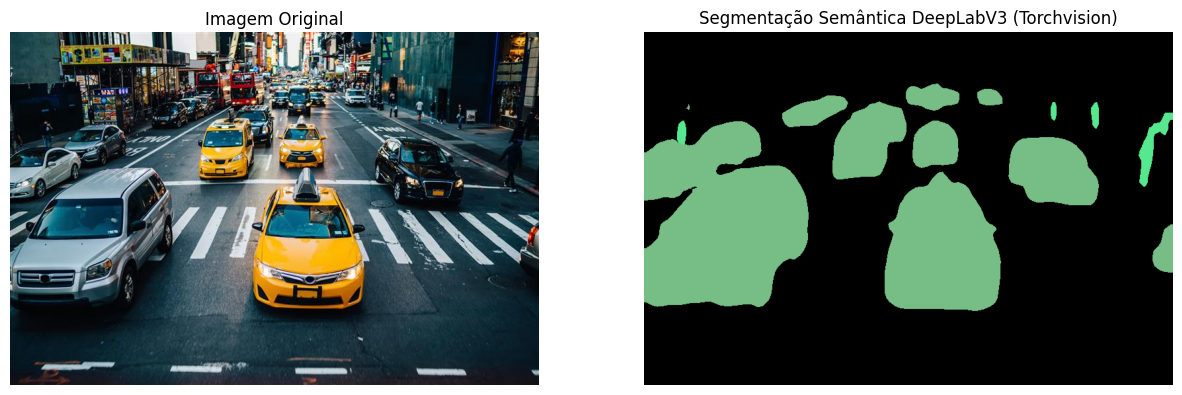

In [11]:
# Definir a paleta de cores para cada uma das 21 classes
coco_classes = [
    '__background__', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

# Listar quais classes do COCO foram identificadas na imagem
detected_class_ids = np.unique(output_predictions)
print("--- Classes detectadas pelo DeepLabV3 (torchvision) ---")
for cid in detected_class_ids:
    print(f"  ID {cid}: {coco_classes[cid]}")

# Criar mapa de cores colorido
colors = np.random.randint(0, 255, size=(len(coco_classes), 3), dtype=np.uint8)
colors[0] = [0, 0, 0] # Background preto

# Mapear pixels para a respectiva cor
colored_mask = colors[output_predictions]

# Plotar imagem original vs máscara de segmentação do torchvision
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
axes[0].imshow(img_rgb)
axes[0].set_title("Imagem Original")
axes[0].axis('off')

axes[1].imshow(colored_mask)
axes[1].set_title("Segmentação Semântica DeepLabV3 (Torchvision)")
axes[1].axis('off')
plt.show()